In [1]:
import os
import sys
import warnings

import numpy as np
import pandas
import seaborn as sns
import statsmodels.formula.api as smf
from mizani.formatters import percent_format
from plotnine import *

warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore")

# Current script folder
current_path = os.getcwd()
dirname = current_path.split("da_case_studies")[0]

# location folders (double check you have this on your pc)
data_in = dirname + "/Data/"
data_out = dirname + "/Data/"
output = dirname + "/output/"
func = dirname + "/Settings/"
sys.path.append(func)

# Import the prewritten helper functions
from py_helper_functions import *

In [3]:
# load vienna
hotels = pd.read_csv(data_in+"hotels-vienna.csv")

In [4]:
hotels = hotels.loc[
    (hotels["accommodation_type"] == "Hotel")
    & (hotels["city_actual"] == "Vienna")
    & (hotels["stars"] >= 3)
    & (hotels["stars"] <= 4)
    & (~hotels["stars"].isnull())
    & (hotels["price"] <= 600)
]

In [5]:
import statsmodels.api as sm
y = hotels["price"]
x = hotels["distance"]
X = sm.add_constant(x)
model = sm.OLS(y,X)
results = model.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.157
Model:                            OLS   Adj. R-squared:                  0.153
Method:                 Least Squares   F-statistic:                     38.20
Date:                Tue, 04 Mar 2025   Prob (F-statistic):           3.39e-09
Time:                        07:23:45   Log-Likelihood:                -1050.3
No. Observations:                 207   AIC:                             2105.
Df Residuals:                     205   BIC:                             2111.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        132.0170      4.474     29.511      0.000     123.197     140.837
distance     -14.4064      2.331     -6.181      0.000     -19.002      -9.811
==============================================================================
Omnibus:                      141.994   Durbin-Watson:                   1.479
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1560.025
Skew:                           2.497   Prob(JB):                         0.00
Kurtosis:                      15.488   Cond. No.                         3.78
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

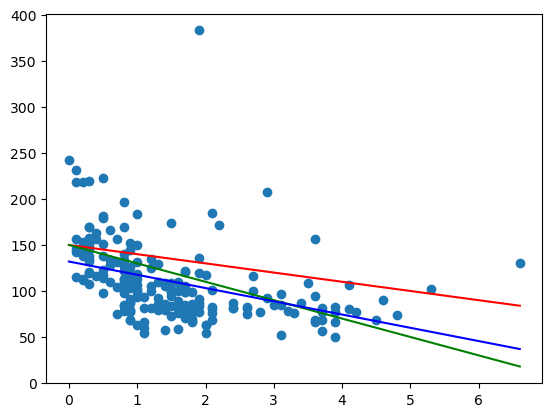

In [8]:
import matplotlib.pyplot as plt
plt.scatter(x,y)
x1 = np.linspace(min(x), max(x), 100)
beta1 = [150, -10]
y1 = beta1[0]+beta1[1]*x1
beta2 = [150, -20]
y2 = beta2[0]+beta2[1]*x1
y3 = results.params[0]+results.params[1]*x1
plt.plot(x1, y1, color='red')
plt.plot(x1, y2, color='green')
plt.plot(x1, y3, color='blue')

In [9]:
# is that really the best line?
SSE1 = np.sum((y-(results.params[0]+results.params[1]*x))**2)
SSE2 = np.sum((y-(beta1[0]+beta1[1]*x))**2)
MAD1 = np.sum(np.abs(y-(results.params[0]+results.params[1]*x)))
MAD2 = np.sum(np.abs(y-(beta1[0]+beta1[1]*x)))
print('SSE1: ',SSE1,' SSE2:',SSE2)
print('MAD1: ',MAD1,' MAD2:',MAD2)

SSE1:  309545.1699622064  SSE2: 441482.0
MAD1:  5498.415163260632  MAD2: 7950.0


Comparison with a line which minimizes the mean absolute deviation

In [11]:
from scipy.optimize import minimize

def objective(beta):
    gamma = 1;
    return np.sum(np.abs(y - beta[0] - beta[1] * x)**gamma)

# Initial guess for the parameters
initial_guess = [results.params[0], results.params[1]]

# Minimize the objective function
result2 = minimize(objective, initial_guess, method='SLSQP')

# Extract the optimal parameters
beta = result2.x

# Print the fitted parameters
print("Intercept:", beta[0]," Starting value:", initial_guess[0])
print("Slope:", beta[1]," Starting value:", initial_guess[1])

Intercept: 124.31558216691288  Starting value: 132.01697270176436
Slope: -14.641085017495564  Starting value: -14.406420427108342


In [13]:
# is that really the best line?
SSE1 = np.sum((y-(results.params[0]+results.params[1]*x))**2)
SSE2 = np.sum((y-(beta[0]+beta[1]*x))**2)
MAD1 = np.sum(np.abs(y-(results.params[0]+results.params[1]*x)))
MAD2 = np.sum(np.abs(y-(beta[0]+beta[1]*x)))
print('SSE1: ',SSE1,' SSE2:',SSE2)
print('MAD1: ',MAD1,' MAD2:',MAD2)

SSE1:  309545.1699622064  SSE2: 323009.32743319566
MAD1:  5498.415163260632  MAD2: 5298.21535059868


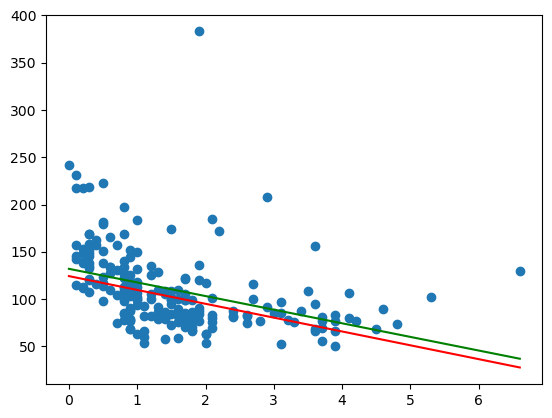

In [14]:
import matplotlib.pyplot as plt
plt.scatter(x,y)
x1 = np.linspace(min(x), max(x), 100)
y1 = beta[0]+beta[1]*x1
y2 = results.params[0]+results.params[1]*x1
plt.plot(x1, y1, color='red')
plt.plot(x1, y2, color='green')

We now explore the robustness of the parameter estimates to the presence of outliers

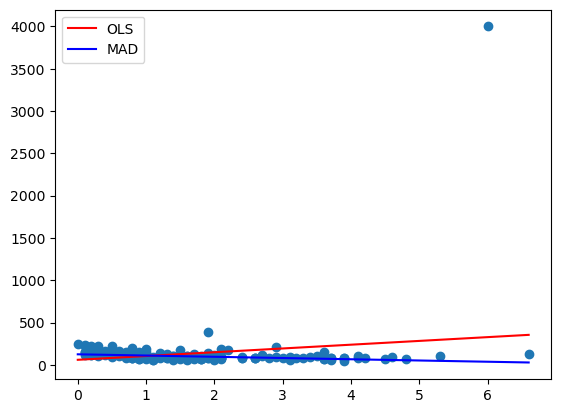

In [16]:
xx = np.append(x,6)
yy = np.append(y,4000)
X = sm.add_constant(xx)
model = sm.OLS(yy,X)
results_OLS = model.fit()
initial_guess = [results_OLS.params[0], results_OLS.params[1]]
results_MAD = minimize(objective, initial_guess, method='SLSQP')
plt.scatter(xx,yy)
x1 = np.linspace(min(xx), max(xx), 100)
y_OLS = results_OLS.params[0]+results_OLS.params[1]*x1
y_MAD = results_MAD.x[0]+results_MAD.x[1]*x1
plt.plot(x1, y_OLS, color='red',label='OLS')
plt.plot(x1, y_MAD, color='blue',label='MAD')
plt.legend(loc='upper left')